### Advanced tutorial: fitting the H$\beta$ line with two Gaussian components and playing with the MCMC samples

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from easyspec.analysis import analysis
analysis = analysis()

easyspec-cleaning version:  1.0.0
easyspec-extraction version:  1.0.0
easyspec-analysis version:  1.0.0


As always, we have to start by loading our data. This time we choose the core of the radio galaxy G4JY45:

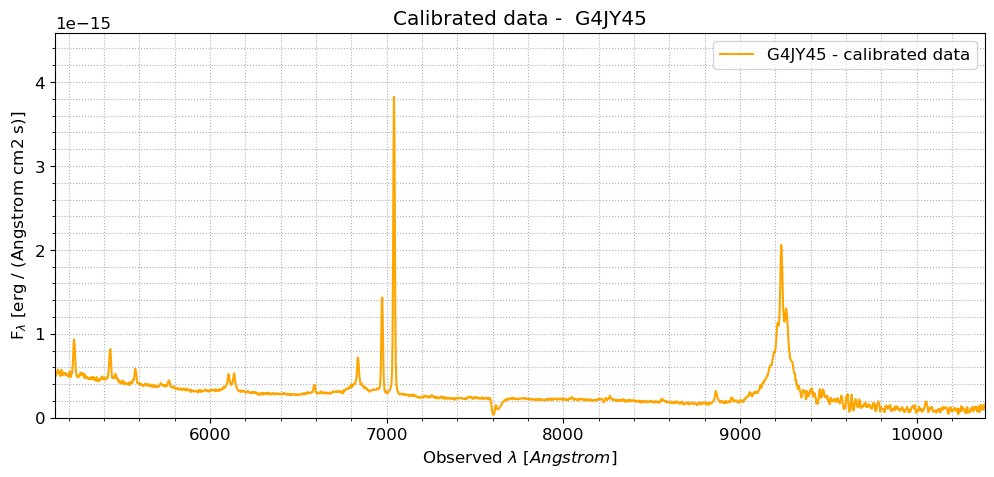

In [3]:
wavelengths, flux_density = analysis.load_calibrated_data("./spec3_G4JY45_results_tutorial/G4JY45_spec_0.dat",
                                          target_name="G4JY45", output_dir = "./spec3_G4JY45_results_tutorial", plot = True)

Now we can set the continuum regions and look for the lines. Here we choose a significance threshold of 12$\sigma$ for line detection. More details on the function below can be found [here](https://github.com/ranieremenezes/easyspec/blob/main/tutorial/spectral_analysis_easyspec.ipynb). 

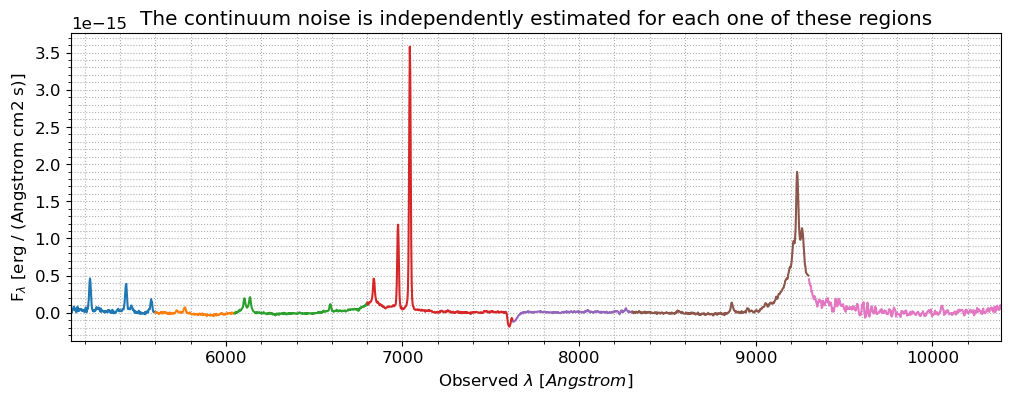

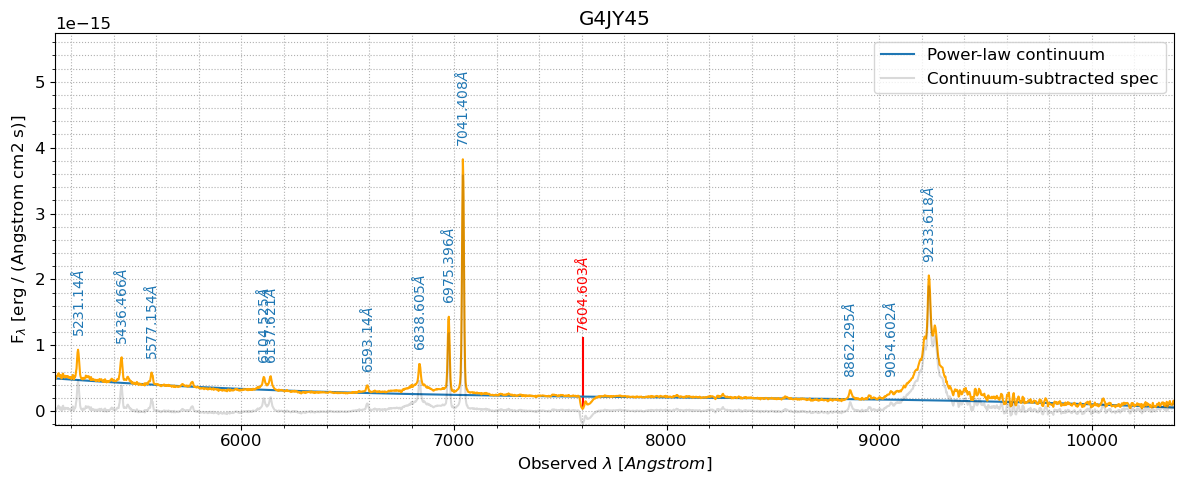

In [4]:
continuum_regions = [[5300,5400],[5800,5900],[6200,6500],[7100,7450],[7800,8000],[8600,8800],[9800,10200]]
continuum_baseline, line_std_deviation, wavelength_peak_positions, peak_heights, line_significance = analysis.find_lines(wavelengths, flux_density,
                    line_significance_sigma = 12, peak_distance = 5,
                    peak_width = 4, method="pl", continuum_regions=continuum_regions, pl_order=3,
                    smooth_window=55,plot_lines = True, plot_regions = True, save_plot = True)

The output variables from this function are:

- `continuum_baseline`: The continuum differential flux obtained from the power-law fit.
- `line_std_deviation`: The estimated standard deviation (i.e., background noise) for each line, based on the continuum regions defined in *continuum_regions*.
- `wavelength_peak_positions`: The peak wavelength positions of all identified lines in the plot above.
- `peak_heights`: The height of each identified line in erg/s/cm²/Å.
- `line_significance`: The significance of each line in $\sigma$.

Notably, *easyspec* identifies a telluric absorption line around **7600 Å**.  

Although multiple lines have been detected, this tutorial focuses only on the **H$\beta$** line, meaning the full **`wavelength_peak_positions`** array is not needed:


In [10]:
wavelength_peak_positions

<Quantity [5231.13964353, 5436.46550413, 5577.15426237, 6104.52537801,
           6137.6213197 , 6593.13999846, 6838.60462819, 6975.39605959,
           7041.40787532, 7604.60336949, 8862.29453011, 9054.60220584,
           9233.61769247] Angstrom>

The H$\beta$ line here is the seventh from left to right, corresponding to the array index 6. From now on we can proceed only with the H$\beta$ line by using:

In [11]:
Hbeta_peak_position = wavelength_peak_positions[6].value

If we use only this value in the function below, *easyspec* will fit the line with a single model.  

The trick is to input this value twice, allowing *easyspec* to recognize two lines peaking at the same (or a similar) wavelength. Additionally, we can set an initial peak height for both components based on the measured height of the **H$\beta$** line, stored in the variable `peak_heights`.

In [12]:
Hbeta_height = peak_heights[6].value

The variables going into the fit_lines() function below can then be defined as:

In [13]:
# Hbeta with 2 components:
wavelength_peak_positions_slice = [Hbeta_peak_position,Hbeta_peak_position]
rest_frame_line_wavelengths = [4861.333,4861.333]  # We use the same value for the position of both components in the wavelength axis.
line_names = ["Hbeta_narrow","Hbeta_broad"]
peak_heights_slice = [Hbeta_height,Hbeta_height/2]  # Our initial guess for the broad component is smaller than for the narrow component. 
line_std_deviation_slice = [line_std_deviation[6],line_std_deviation[6]]
which_models = ["Gaussian","Gaussian"] # Or simply which_models = "Gaussian"
overplot_archival_lines = ["H","He","O","Ne","S","N"] # Type ["all"] to see all lines in our database.

## Setting the priors

Since we are ignoring the nearby [O III] lines, it is advisable to manually set the priors for the MCMC. However, if you find this unnecessary, simply set: `priors = None`

Setting priors can be tricky. For the peak position, we define a range from −100 Å to +70 Å relative to `Hbeta_peak_position`.

For `peak_height`, we must input the normalized values required for the MCMC. These can be estimated using the function `estimate_norm_height()`. Let's begin with the tallest component:

In [14]:
prior_height_narrow = analysis.estimate_norm_height(wavelengths, flux_density, continuum_baseline, Hbeta_peak_position, Hbeta_height)
prior_height_narrow

4.5783335759429145

For the broad component we have:

In [17]:
prior_height_broad = analysis.estimate_norm_height(wavelengths, flux_density, continuum_baseline, Hbeta_peak_position, Hbeta_height/2)
prior_height_broad

1.0054259472242177

So a reasonable range for the priors on component heights is **0.5 to 2 times** these values. You can adjust this range to be more restrictive or more flexible as needed.  

The manually defined priors are shown below:


In [18]:
priors = [[[Hbeta_peak_position-100,Hbeta_peak_position+70],[0.5*prior_height_narrow, 2*prior_height_narrow],[2,20]], # narrow component
          [[Hbeta_peak_position-100,Hbeta_peak_position+70],[0.5*prior_height_broad, 2*prior_height_broad],[30,70]]] # broad component

This step can be challenging and **may require multiple attempts before achieving a proper fit**. If it doesn't work, remember that you can always set `priors = None` and easyspec will select them automatically for you. However, manually defining priors gives you much greater control when estimating line parameters.

In my case, I had to try four times before finding a suitable set of priors for both components.


**Note:**
>Be careful with the input **peak_height**! For instance, if you set the height of the broad component as Hbeta_height/3, the normalized value becomes negative (i.e., −0.185), causing the fit to fail (since we have an emission, and not absorption line). This happens because one of the steps in the normalization is the subtraction **peak_height - local_continuum**, i.e. in our case here the input value Hbeta_height/3 is already below the continuum. **Don't do that**!

## Running the MCMC

Ok, now we use the priors plus the other variables defined above in the function fit_lines() to fit both components:

Running burn-in...


100%|█████████████████████████████████████████| 100/100 [00:02<00:00, 34.86it/s]


Running production...


100%|█████████████████████████████████████████| 100/100 [00:02<00:00, 35.35it/s]


Multiprocessing took 5.8 seconds
Archival lines are taken from NIST Atomic Spectra database: https://www.nist.gov/pml/atomic-spectra-database
We adopt vacuum wavelengths for lines with wavelengths < 2000 Angstroms and air wavelengths for lines with wavelengths > 2000 Angstroms.
If you use these lines in your research, please cite the NIST Atomic Spectra database appropriately.


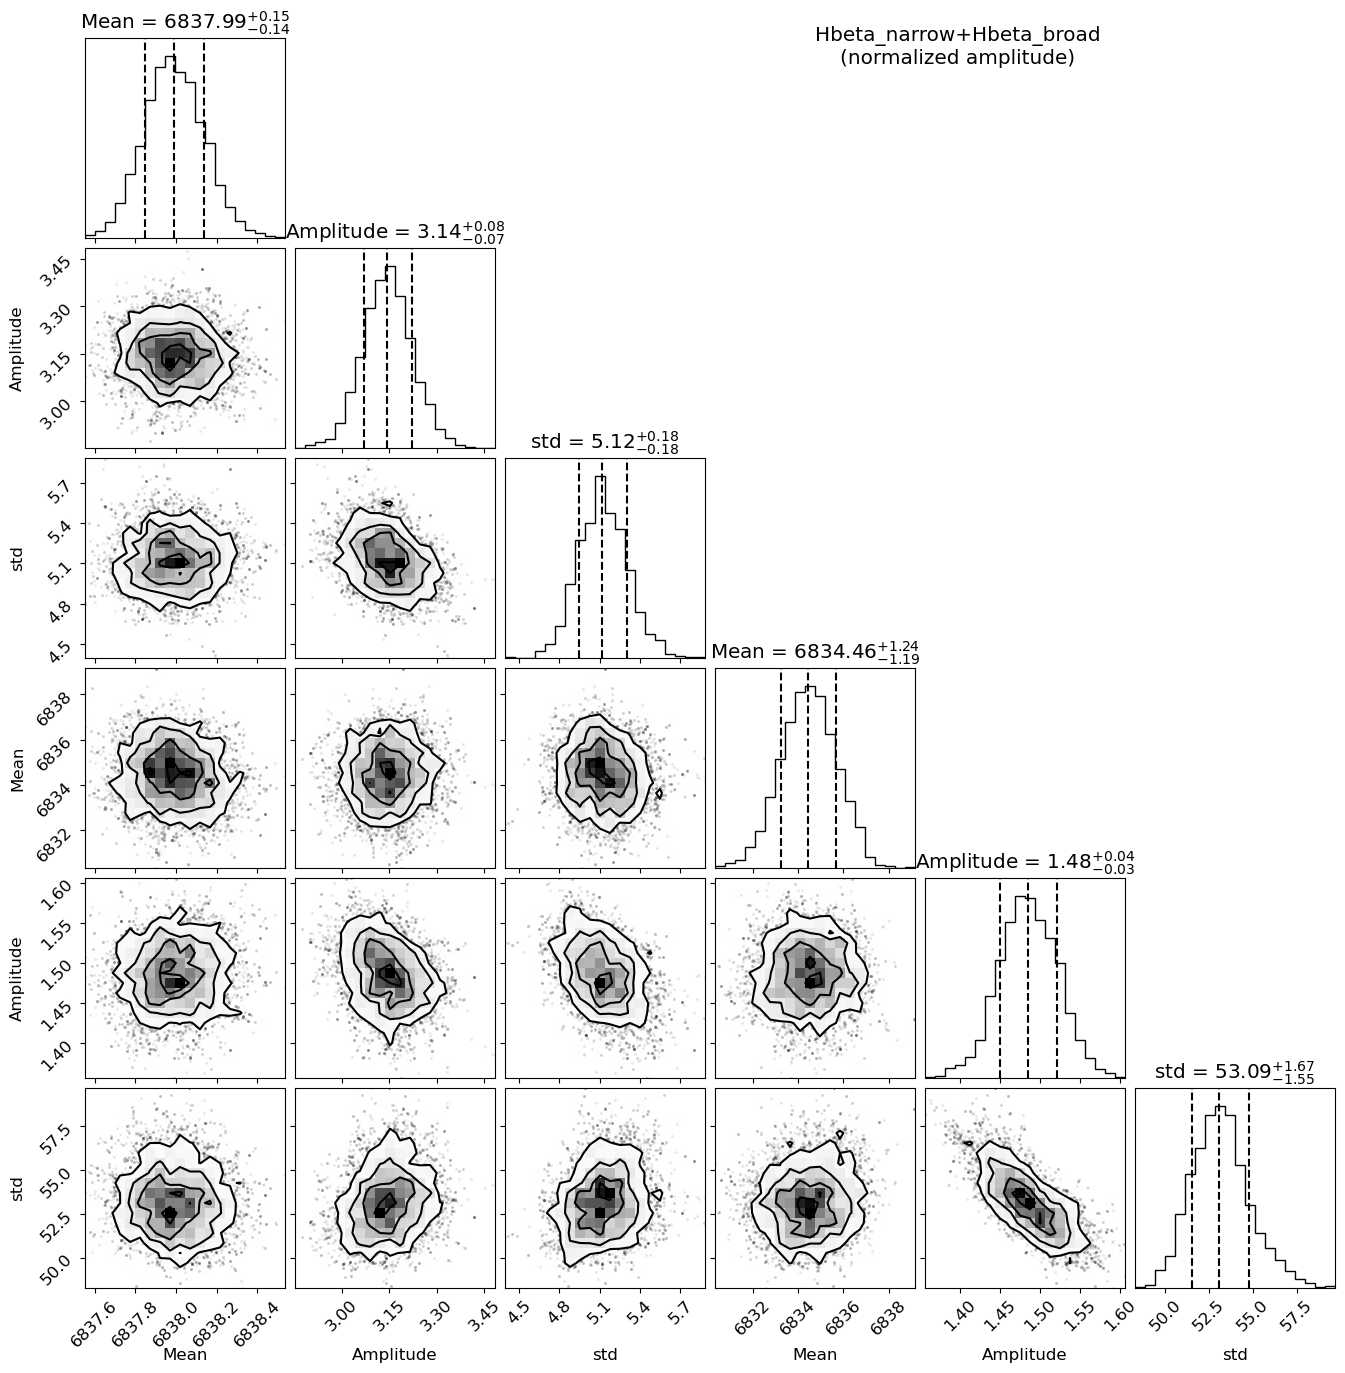

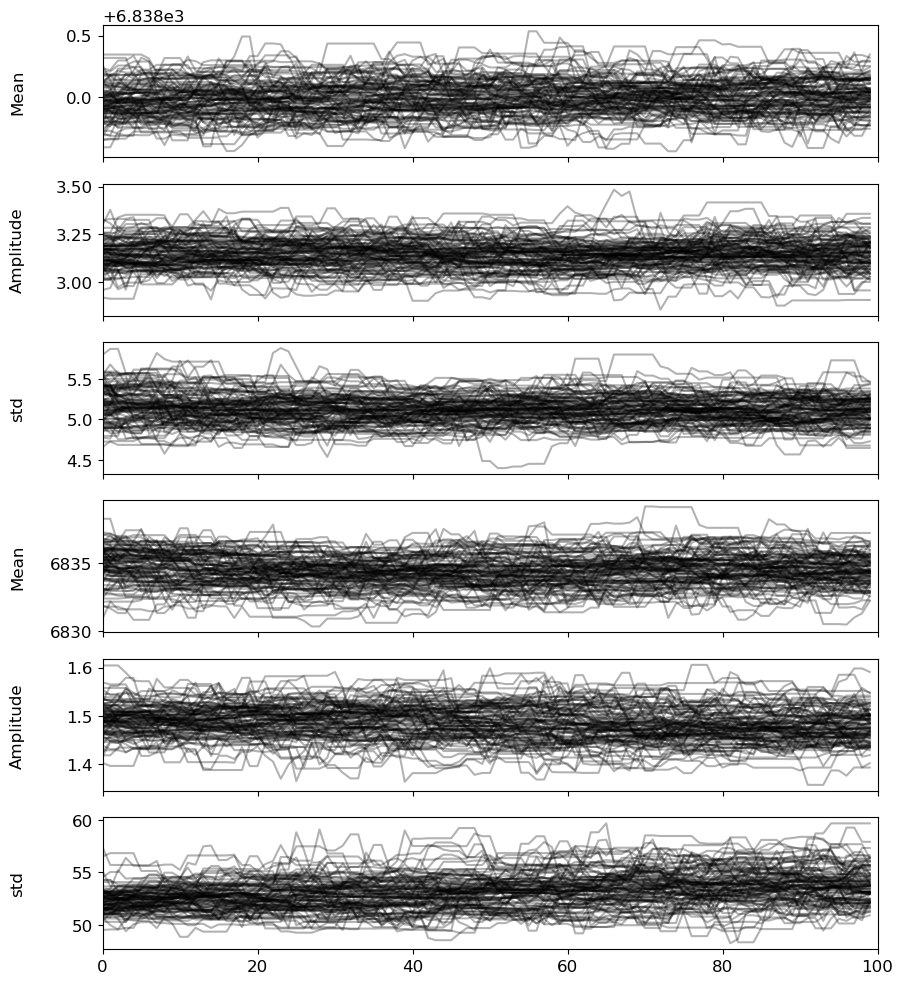

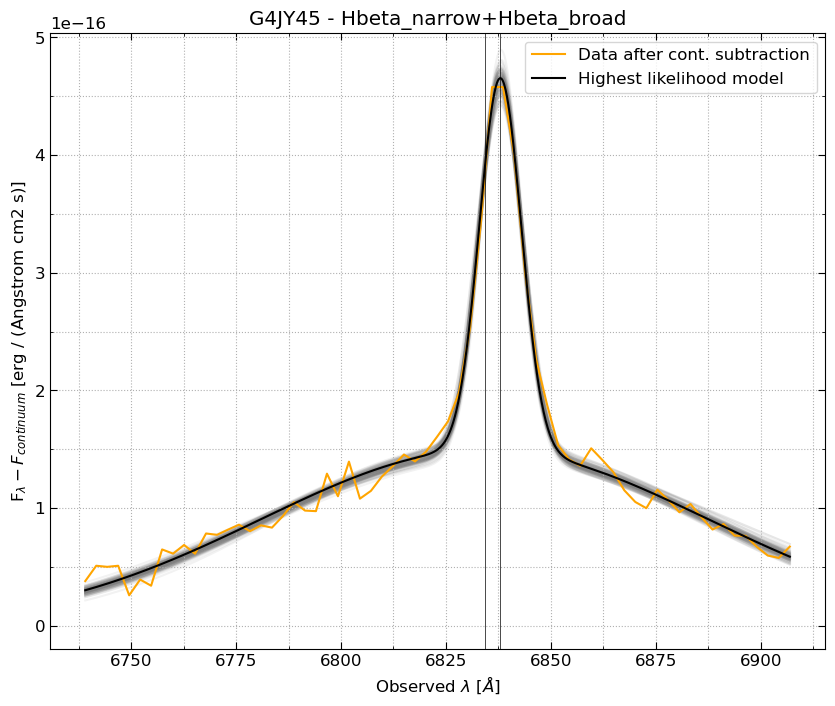

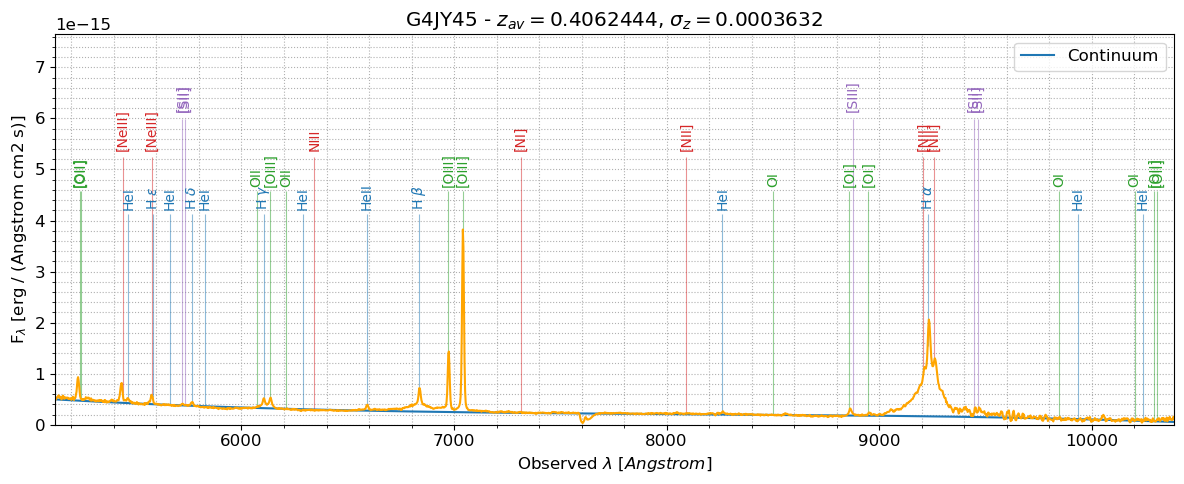

In [19]:
par_values_list , par_values_errors_list ,par_names_list, samples_list, line_windows = analysis.fit_lines(wavelengths,
                    flux_density, continuum_baseline, wavelength_peak_positions_slice, rest_frame_line_wavelengths,
                    peak_heights_slice, line_std_deviation_slice, blended_line_min_separation = 70, which_models=which_models,
                    line_names = line_names, overplot_archival_lines = overplot_archival_lines, priors = priors,
                    MCMC_walkers = 100, MCMC_iterations = 100, N_cores = 4, plot_spec = True, plot_MCMC = True, save_results=True)

You can access all fit information about the two components in the variables below:

In [20]:
par_names_list, par_values_list, par_values_errors_list

([['redshift', 'Mean', 'Amplitude', 'fwhm_Gauss'],
  ['redshift', 'Mean', 'Amplitude', 'fwhm_Gauss']],
 [[0.4066075605024253,
   6837.987751919936,
   3.1441543250278667e-16,
   12.057095076634113],
  [0.40588120250774645,
   6834.45668383059,
   1.484520677080912e-16,
   125.0083413234587]],
 [[[2.875770802617059e-05, 3.121924347554658e-05],
   [0.13980079503198795, 0.1517671385427093],
   [7.499687719862091e-18, 7.767166262441982e-18],
   [0.41293439828025535, 0.4318715736454366]],
  [[0.00024547045606472084, 0.00025567363709763495],
   [1.1933136285924775, 1.242914689252757],
   [3.467056979037286e-18, 3.67060738019398e-18],
   [3.6593516168204996, 3.9342295555844813]]])

while the MCMC parameter samples are stored in the variable **samples_list**. We discuss about this variable at the end of this tutorial.

Now we can use this as input for the function line_physics() below. If you want to access the parameters of the individual components, you should use the "modeled_XXXXX" values below. If instead you want to consider the line as a whole, you should use the "profile_XXXXX" values.

By **profile**, we mean that the results are obtained by fitting a spline to the measured spectral profile of the line. This method is independent of the modeling and treats everything within the selected wavelength window as a single line.

Below, the plot is done twice because *easyspec* interprets the two H$\beta$ components as separate, independent lines.

<Figure size 1200x400 with 0 Axes>

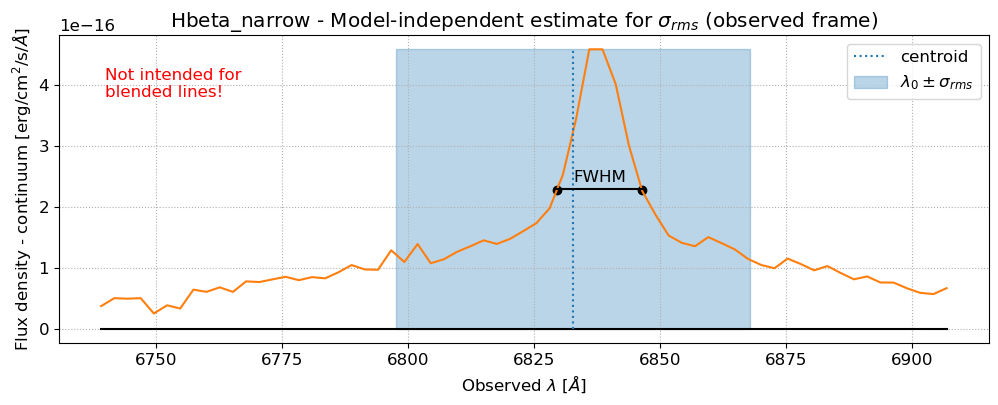

<Figure size 1200x400 with 0 Axes>

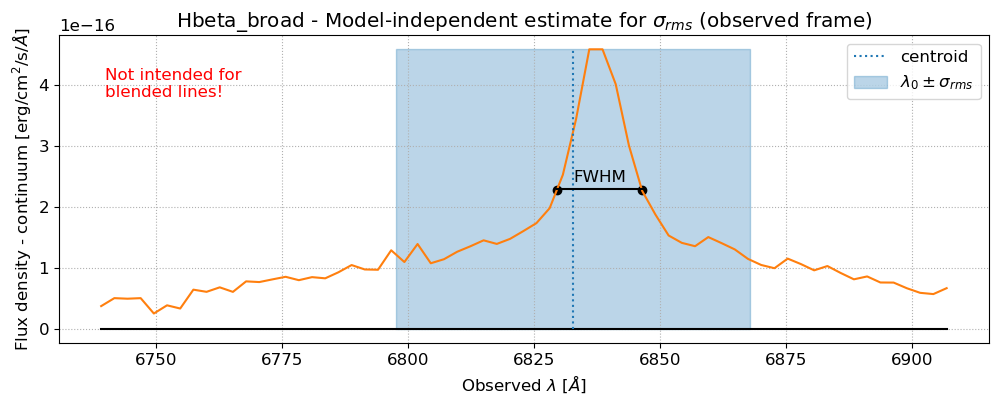

In [21]:
profile_equiv_width_rest_frame, modeled_equiv_width_rest_frame, profile_integrated_flux, modeled_integrated_flux, profile_rest_frame_disp_velocity, modeled_rest_frame_disp_velocity, profile_line_dispersion_rest_frame, profile_rest_frame_fwhm, modeled_rest_frame_fwhm = analysis.line_physics(wavelengths, flux_density, continuum_baseline, par_values_list, par_values_errors_list, par_names_list, line_windows, line_std_deviation, plot = True)

The results from this function are **always** given in the rest frame. The description about all these output variables can be found [here](https://github.com/ranieremenezes/easyspec/blob/main/tutorial/spectral_analysis_easyspec.ipynb).

You will notice below that the "modeled_XXXXX" variables give you two distinct values, one for each component, while the "profile_XXXXX" variables give you repeated results. This happens because the "profile" method, where we fit a spline to the observed spectrum cannot distinguish between components (or nearby blended lines), i.e., it considers everything in the given wavelength window (i.e. the wavelength interval shown in the plot above) as been part of the line.

In [22]:
profile_equiv_width_rest_frame

<Quantity [[-57.95916215,   0.15774977,   0.15775057],
           [-57.98910715,   0.18085966,   0.18088371]] Angstrom>

In [23]:
modeled_equiv_width_rest_frame

<Quantity [[-11.1737371 ,   0.1331242 ,   0.15194813],
           [-48.27336745,   0.43978334,   0.4385681 ]] Angstrom>

In [24]:
profile_integrated_flux

<Quantity [[2.09315987e-14, 5.69687625e-17, 5.69687625e-17],
           [2.09597925e-14, 6.52680514e-17, 6.52680514e-17]] erg / (cm2 s)>

In [25]:
modeled_integrated_flux

<Quantity [[4.03532716e-15, 4.80769249e-17, 5.48750802e-17],
           [1.74481005e-14, 1.58927683e-16, 1.58488363e-16]] erg / (cm2 s)>

In [26]:
profile_rest_frame_disp_velocity

<Quantity [[1539.27784055,   21.20810051,   21.20810467],
           [1540.07311882,   20.59318416,   20.59333314]] km / s>

In [27]:
modeled_rest_frame_disp_velocity

<Quantity [[ 224.47984092,    7.68804156,    8.04061522],
           [2328.61653166,   68.16526465,   73.28560547]] km / s>

In [28]:
profile_line_dispersion_rest_frame

<Quantity [[24.96040832,  0.08318079,  0.08318107],
           [24.97330428,  0.0784932 ,  0.07850348]] Angstrom>

In [29]:
profile_rest_frame_fwhm

<Quantity [[11.98279914,  0.83725771,  0.83725772],
           [11.98899013,  0.87029983,  0.87030005]] Angstrom>

In [30]:
modeled_rest_frame_fwhm

<Quantity [[ 8.57175478,  0.29356765,  0.30703067],
           [88.91813981,  2.60293452,  2.79845497]] Angstrom>

## The MCMC samples

The posterior distributions for all models are stored in the variable `samples_list`. Even if we have two components for the H$\beta$ line, we have only one set of parameters since these two components are modeled together, i.e., we have only the set `samples_list[0]`. The order of parameters in each line are always:

'Mean', 'Amplitude', 'fwhm_Gauss'

In our particular case with two components, we simply have:

'Mean', 'Amplitude', 'fwhm_Gauss', 'Mean', 'Amplitude', 'fwhm_Gauss'

Let's see how the `samples_list` looks like:

In [31]:
samples_list

[array([[6.83801025e+03, 3.11018814e+00, 5.07393596e+00, 6.83466756e+03,
         1.51983808e+00, 5.25400654e+01],
        [6.83796343e+03, 3.23730451e+00, 5.42450015e+00, 6.83630155e+03,
         1.47716383e+00, 5.19577149e+01],
        [6.83798522e+03, 3.12436913e+00, 5.32730040e+00, 6.83583863e+03,
         1.47869925e+00, 5.26444235e+01],
        ...,
        [6.83798919e+03, 3.20566404e+00, 5.35087195e+00, 6.83439048e+03,
         1.46129848e+00, 5.35861615e+01],
        [6.83802863e+03, 3.12704660e+00, 5.27468318e+00, 6.83565380e+03,
         1.44074534e+00, 5.64447202e+01],
        [6.83806729e+03, 3.13522764e+00, 5.15715740e+00, 6.83366251e+03,
         1.49546291e+00, 5.30219336e+01]])]

Now let's check the histograms for the peak position of the two components:

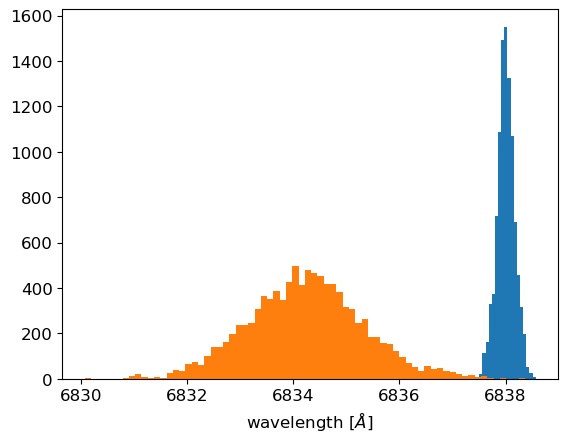

In [96]:
plt.hist(samples_list[0][:,0],bins=20);
plt.hist(samples_list[0][:,3],bins=70);
plt.xlabel("wavelength [$\AA$]");

We can also look for covariances:

<AxesSubplot:xlabel='Peak position - narrow component [Angstrom]', ylabel='Amplitude (normalized)'>

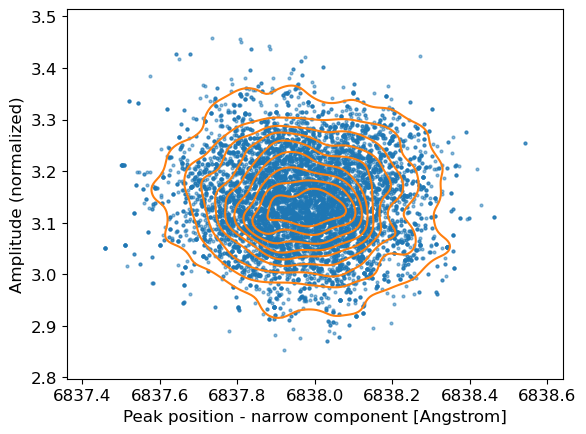

In [76]:
plt.plot(samples_list[0][:,0],samples_list[0][:,1],"o",markersize=2,alpha=0.5)
plt.ylabel("Amplitude (normalized)")
plt.xlabel("Peak position - narrow component [Angstrom]")
import seaborn as sns
sns.kdeplot(x=samples_list[0][:,0],y=samples_list[0][:,1])

We see that these variables are independent. 